# Анализ влияния состава признаков и объема выборки на качество прогноза ранга текущего пожара по обученному дереву решений


## Цель работы

В работе исследуется, как на качество прогноза ранга текущего пожара влияют:

- объем обучающей выборки;
- состав признаков;
- использование базовых и обогащённых признаков;
- выбор алгоритма классификации.

Сравнение проводится для двух наборов данных:

- малого набора;
- большого набора.

Для каждого набора данных рассматриваются два алгоритма:

- дерево решений;
- случайный лес


## Структура исследования

1. Исходные данные.
2. Загрузка малого и большого наборов данных.
3. Подготовка признаков и схема оценки.
4. Сравнение моделей на малом и большом наборах данных.
5. Сравнение базовых и обогащённых признаков.
6. Исследование влияния объема обучающей выборки.
7. Оценка на полном доступном датасете.
8. Итоговые модели и выводы.
9. Воспроизводимость.

In [1]:
import sqlite3
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
        if (candidate / "clean_df_with_rank.csv").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Не удалось определить корень репозитория")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from fire_es.model_train import visualize_tree
from fire_es.rank_tz_contract import get_feature_set_spec, prepare_feature_payload

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
np.set_printoptions(suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

## 1. Исходные данные

В исследовании рассматриваются два массива наблюдений, различающихся способом формирования:

- очищенный массив наблюдений;
- дедуплицированный массив наблюдений, в котором для каждого события сохраняется одна запись.

Целевой переменной является ранг пожара.

Для обеспечения сопоставимости результатов качество моделей оценивается по единой схеме:

- стратифицированное случайное разбиение на обучающую и тестовую части;
- отдельная стратифицированная кросс-валидация на полном массиве наблюдений.


In [2]:
SEED = 42

SMALL_DATA_PATH = REPO_ROOT / "clean_df_with_rank.csv"
LARGE_DB_PATH = REPO_ROOT / "WS" / "fire_es_workspace_reparsed_20260422_003803_ranked" / "fire_es.sqlite"
ARTIFACTS_DIR = REPO_ROOT / "output" / "jupyter-notebook" / "decision-tree-rank-study-artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

DT_MODEL_PARAMS = {
    "max_depth": 10,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "random_state": SEED,
    "class_weight": "balanced",
}

RF_MODEL_PARAMS = {
    "n_estimators": 100,
    "max_depth": 15,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "random_state": SEED,
    "class_weight": "balanced",
    "n_jobs": -1,
}

MODEL_CONFIGS = {
    "decision_tree": {
        "label": "Дерево решений",
        "params": DT_MODEL_PARAMS,
    },
    "random_forest": {
        "label": "Случайный лес",
        "params": RF_MODEL_PARAMS,
    },
}

RETROSPECTIVE_FULL_SAFE_FEATURES = [
    "region_code",
    "settlement_type_code",
    "fire_protection_code",
    "enterprise_type_code",
    "building_floors",
    "fire_floor",
    "fire_resistance_code",
    "source_item_code",
    "distance_to_station",
    "day_of_week",
    "month",
    "season",
    "is_weekend",
    "is_high_rise",
    "is_super_high_rise",
    "basement_fire",
    "top_floor_fire",
    "fire_floor_ratio",
    "is_far",
    "is_very_far",
    "distance_category",
    "building_floors_bin",
    "risk_category_missing",
    "fpo_class_missing",
    "t_detect_min",
    "t_report_min",
    "t_arrival_min",
    "t_first_hose_min",
    "delta_detect_to_report",
    "delta_report_to_arrival",
    "delta_arrival_to_hose",
    "fatalities",
    "injuries",
    "direct_damage",
    "people_saved",
    "people_evacuated",
    "assets_saved",
    "t_contained_min",
    "t_extinguished_min",
]

FEATURE_SET_DEFINITIONS = {
    "dispatch_initial_safe": {
        "feature_order": get_feature_set_spec("dispatch_initial_safe")["feature_order"],
        "label": "10 признаков: при сообщении о пожаре",
        "family": "Базовые признаки",
        "stage_note": "Используются признаки, которые известны на начальном этапе после сообщения о пожаре.",
        "engineering_source": "dispatch_initial_safe",
    },
    "arrival_update_safe": {
        "feature_order": get_feature_set_spec("arrival_update_safe")["feature_order"],
        "label": "13 признаков: после прибытия",
        "family": "Базовые признаки",
        "stage_note": "Добавляются признаки, которые становятся известны после прибытия подразделений.",
        "engineering_source": "arrival_update_safe",
    },
    "first_hose_update_safe": {
        "feature_order": get_feature_set_spec("first_hose_update_safe")["feature_order"],
        "label": "15 признаков: после подачи первого ствола",
        "family": "Базовые признаки",
        "stage_note": "Добавляются признаки, которые становятся известны после подачи первого ствола.",
        "engineering_source": "first_hose_update_safe",
    },
    "enhanced_tactical": {
        "feature_order": get_feature_set_spec("enhanced_tactical")["feature_order"],
        "label": "31 признак: расширенный оперативный набор",
        "family": "Обогащённые признаки",
        "stage_note": "Это поздний оперативный набор: к базовым признакам добавлены производные характеристики объекта, даты и времени реагирования.",
        "engineering_source": "enhanced_tactical",
    },
    "retrospective_full_safe": {
        "feature_order": RETROSPECTIVE_FULL_SAFE_FEATURES,
        "label": "39 признаков: постфактум-набор для итогового анализа",
        "family": "Постфактум-признаки",
        "stage_note": "Этот набор используется только после завершения пожара и сбора полной информации. Он нужен для итогового анализа и сверки, а не для оперативного решения.",
        "engineering_source": "enhanced_tactical",
    },
}

FEATURE_SETS = list(FEATURE_SET_DEFINITIONS.keys())
FEATURE_SET_LABELS = {key: value["label"] for key, value in FEATURE_SET_DEFINITIONS.items()}
FEATURE_SET_FAMILY = {key: value["family"] for key, value in FEATURE_SET_DEFINITIONS.items()}

RANK_TO_CLASS = {
    1.0: 1,
    1.5: 2,
    2.0: 3,
    3.0: 4,
    4.0: 5,
    5.0: 6,
}
CLASS_TO_RANK = {value: key for key, value in RANK_TO_CLASS.items()}
CLASS_LABELS = [CLASS_TO_RANK[idx] for idx in sorted(CLASS_TO_RANK)]

WORK_CONFIG = pd.DataFrame(
    [
        {"Параметр": "Рассматриваемые массивы наблюдений", "Значение": "очищенный и канонический"},
        {"Параметр": "Целевая переменная", "Значение": "ранг пожара"},
        {"Параметр": "Алгоритмы", "Значение": ", ".join(MODEL_CONFIGS[key]["label"] for key in MODEL_CONFIGS)},
        {"Параметр": "Группы наборов признаков", "Значение": ", ".join(FEATURE_SET_LABELS[key] for key in FEATURE_SETS)},
        {"Параметр": "Фиксированное значение random_state", "Значение": str(SEED)},
    ]
)
WORK_CONFIG


,Параметр,Значение
0,Рассматриваемые массивы наблюдений,очищенный и канонический
1,Целевая переменная,ранг пожара
2,Алгоритмы,"Дерево решений, Случайный лес"
3,Группы наборов признаков,"10 признаков: при сообщении о пожаре, 13 признаков: после прибытия, 15 признаков: после подачи первого ствола, 31 признак: расширенный оперативный набор, 39..."
4,Фиксированное значение random_state,42


## 2. Загрузка малого и большого наборов данных


In [3]:
small_df = pd.read_csv(SMALL_DATA_PATH)
small_df["dataset_key"] = "small"
small_df["dataset_label"] = "Малый набор"

large_query = '''
SELECT
    source_sheet,
    source_period,
    region_code,
    region_text,
    fire_date,
    year,
    month,
    settlement_type_code,
    fire_protection_code,
    risk_category_code,
    fpo_class_code,
    enterprise_type_code,
    building_floors,
    fire_floor,
    fire_resistance_code,
    source_item_code,
    distance_to_station,
    fatalities,
    injuries,
    direct_damage,
    people_saved,
    people_evacuated,
    assets_saved,
    t_detect_min,
    t_report_min,
    t_arrival_min,
    t_first_hose_min,
    t_contained_min,
    t_extinguished_min,
    rank_tz
FROM fires
WHERE rank_tz IS NOT NULL
  AND COALESCE(source_sheet, '') <> 'LPR_MANUAL_INPUT'
  AND COALESCE(is_canonical_event_record, 1) = 1
'''
with sqlite3.connect(LARGE_DB_PATH) as conn:
    large_df = pd.read_sql(large_query, conn)

large_df["dataset_key"] = "large"
large_df["dataset_label"] = "Большой набор"

dataset_summary_df = pd.DataFrame(
    [
        {
            "Набор данных": "Малый набор",
            "Число записей": int(len(small_df)),
            "Число столбцов": int(small_df.shape[1]),
            "Минимальный год": int(pd.to_numeric(small_df["year"], errors="coerce").dropna().min()),
            "Максимальный год": int(pd.to_numeric(small_df["year"], errors="coerce").dropna().max()),
        },
        {
            "Набор данных": "Большой набор",
            "Число записей": int(len(large_df)),
            "Число столбцов": int(large_df.shape[1]),
            "Минимальный год": int(pd.to_numeric(large_df["year"], errors="coerce").dropna().min()),
            "Максимальный год": int(pd.to_numeric(large_df["year"], errors="coerce").dropna().max()),
        },
    ]
)
dataset_summary_df

,Набор данных,Число записей,Число столбцов,Минимальный год,Максимальный год
0,Малый набор,6340,103,2000,2020
1,Большой набор,3228,32,2000,2020


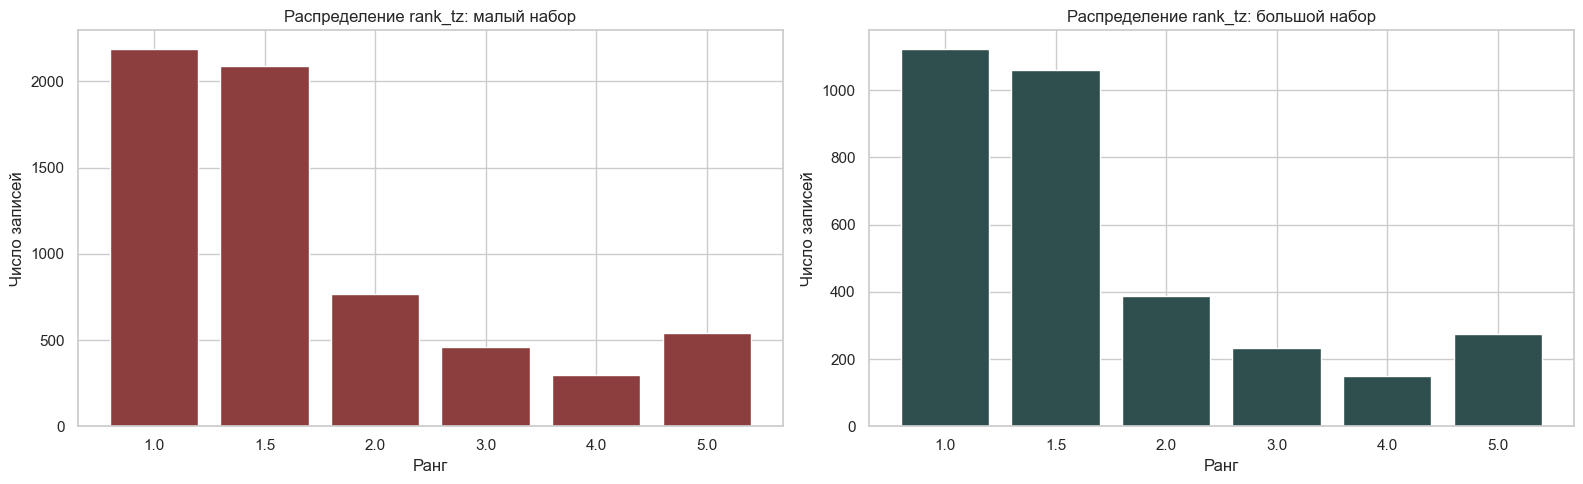

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

small_rank = small_df["rank_tz"].value_counts().sort_index()
large_rank = large_df["rank_tz"].value_counts().sort_index()

axes[0].bar(small_rank.index.astype(str), small_rank.values, color="#8c3d3d")
axes[0].set_title("Распределение rank_tz: малый набор")
axes[0].set_xlabel("Ранг")
axes[0].set_ylabel("Число записей")

axes[1].bar(large_rank.index.astype(str), large_rank.values, color="#2f4f4f")
axes[1].set_title("Распределение rank_tz: большой набор")
axes[1].set_xlabel("Ранг")
axes[1].set_ylabel("Число записей")

plt.tight_layout()
plt.show()


## 3. Подготовка признаков и схема оценки

В работе используются пять наборов признаков.

1. **10 признаков: при сообщении о пожаре**  
   Этот набор выбран потому, что он соответствует информации, известной на начальном этапе после сообщения о пожаре.

2. **13 признаков: после прибытия**  
   Этот набор выбран потому, что к ранним признакам добавляются признаки, которые становятся известны после прибытия подразделений.

3. **15 признаков: после подачи первого ствола**  
   Этот набор выбран потому, что к предыдущему набору добавляются признаки, известные после подачи первого ствола.

4. **31 признак: расширенный оперативный набор**  
   Этот набор выбран потому, что к оперативным признакам добавляются производные признаки по объекту, дате и временам реагирования.

5. **39 признаков: постфактум-набор для итогового анализа**  
   Этот набор выбран потому, что он использует максимально полный набор безопасных признаков, доступных после завершения пожара и сбора итоговой информации. Он нужен для итогового анализа и сверки, а не для оперативного решения.

Во всех основных экспериментах применяется единая схема оценки:

- стратифицированное случайное разбиение;
- одинаковое значение `random_state = 42`;
- одинаковые метрики качества для всех моделей.

In [5]:
def build_estimator(model_name: str):
    if model_name == "decision_tree":
        return DecisionTreeClassifier(**DT_MODEL_PARAMS)
    if model_name == "random_forest":
        return RandomForestClassifier(**RF_MODEL_PARAMS)
    raise ValueError(f"Неизвестный алгоритм: {model_name}")

def prepare_xy(frame: pd.DataFrame, feature_set: str):
    feature_info = FEATURE_SET_DEFINITIONS[feature_set]
    engineering_source = feature_info["engineering_source"]
    feature_order = feature_info["feature_order"]
    enriched = prepare_feature_payload(frame.copy(), feature_set=engineering_source)
    X = enriched.loc[:, feature_order].apply(pd.to_numeric, errors="coerce")
    y = frame["rank_tz"].map(RANK_TO_CLASS)
    mask = y.notna()
    X = X.loc[mask].reset_index(drop=True)
    y = y.loc[mask].astype(int).reset_index(drop=True)
    meta = frame.loc[mask].reset_index(drop=True)
    return X, y, meta, feature_order

def fit_random_split(frame: pd.DataFrame, feature_set: str, model_name: str, test_size: float = 0.2, random_state: int = SEED):
    X, y, meta, feature_order = prepare_xy(frame, feature_set)
    indices = np.arange(len(X))
    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

    model = build_estimator(model_name)
    model.fit(X_train_imp, y_train)
    y_pred = model.predict(X_test_imp)

    metrics = {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "f1_macro": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
        "confusion_matrix": confusion_matrix(y_test, y_pred, labels=sorted(CLASS_TO_RANK)).tolist(),
    }

    return {
        "model": model,
        "imputer": imputer,
        "feature_order": feature_order,
        "metrics": metrics,
        "train_size": int(len(train_idx)),
        "test_size": int(len(test_idx)),
        "frame": frame.reset_index(drop=True),
        "train_idx": train_idx,
        "test_idx": test_idx,
        "X_train": X_train_imp,
        "X_test": X_test_imp,
        "y_train": y_train,
        "y_test": y_test,
    }

def stratified_cv(frame: pd.DataFrame, feature_set: str, model_name: str, n_splits: int = 5):
    X, y, meta, feature_order = prepare_xy(frame, feature_set)
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rows = []
    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        imputer = SimpleImputer(strategy="median")
        X_train_imp = imputer.fit_transform(X_train)
        X_test_imp = imputer.transform(X_test)

        model = build_estimator(model_name)
        model.fit(X_train_imp, y_train)
        y_pred = model.predict(X_test_imp)

        rows.append(
            {
                "fold": fold_id,
                "accuracy": float(accuracy_score(y_test, y_pred)),
                "f1_macro": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
                "f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
                "train_size": int(len(train_idx)),
                "test_size": int(len(test_idx)),
            }
        )
    return pd.DataFrame(rows)

def plot_confusion(ax, cm, title):
    sns.heatmap(
        np.asarray(cm),
        annot=True,
        fmt="d",
        cmap="YlOrBr",
        xticklabels=CLASS_LABELS,
        yticklabels=CLASS_LABELS,
        cbar=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")

## 4. Сравнение моделей на малом и большом наборах данных


In [6]:
dataset_map = {
    "small": {"label": "Малый набор", "frame": small_df},
    "large": {"label": "Большой набор", "frame": large_df},
}

experiment_rows = []
experiment_results = {}

for dataset_key, dataset_info in dataset_map.items():
    for feature_set in FEATURE_SETS:
        for model_name, model_info in MODEL_CONFIGS.items():
            result = fit_random_split(dataset_info["frame"], feature_set, model_name, test_size=0.2, random_state=SEED)
            experiment_results[(dataset_key, feature_set, model_name)] = result
            experiment_rows.append(
                {
                    "dataset_key": dataset_key,
                    "feature_set_key": feature_set,
                    "Набор данных": dataset_info["label"],
                    "Алгоритм": model_info["label"],
                    "Тип признаков": FEATURE_SET_FAMILY[feature_set],
                    "Набор признаков": FEATURE_SET_LABELS[feature_set],
                    "Число признаков": len(result["feature_order"]),
                    "Число записей": int(len(dataset_info["frame"])),
                    "Размер обучающей части": result["train_size"],
                    "Размер контрольной части": result["test_size"],
                    "Точность": result["metrics"]["accuracy"],
                    "Макро-F1": result["metrics"]["f1_macro"],
                    "Взвешенная F1": result["metrics"]["f1_weighted"],
                }
            )

experiment_df = pd.DataFrame(experiment_rows).sort_values(
    ["Макро-F1", "Точность", "Число признаков"],
    ascending=[False, False, True],
).reset_index(drop=True)

experiment_report_df = experiment_df.sort_values(
    ["Набор данных", "Алгоритм", "Число признаков", "Набор признаков"],
    ascending=[True, True, True, True],
).reset_index(drop=True)

baseline_results_path = ARTIFACTS_DIR / "baseline_all_results.csv"
experiment_report_df.to_csv(baseline_results_path, index=False, encoding="utf-8-sig")
experiment_report_df.round(4)


,dataset_key,feature_set_key,Набор данных,Алгоритм,Тип признаков,Набор признаков,Число признаков,Число записей,Размер обучающей части,Размер контрольной части,Точность,Макро-F1,Взвешенная F1
0,large,dispatch_initial_safe,Большой набор,Дерево решений,Базовые признаки,10 признаков: при сообщении о пожаре,10,3228,2582,646,0.2012,0.1716,0.2190
1,large,arrival_update_safe,Большой набор,Дерево решений,Базовые признаки,13 признаков: после прибытия,13,3228,2582,646,0.1920,0.1758,0.2039
2,large,first_hose_update_safe,Большой набор,Дерево решений,Базовые признаки,15 признаков: после подачи первого ствола,15,3228,2582,646,0.1625,0.1514,0.1778
3,large,enhanced_tactical,Большой набор,Дерево решений,Обогащённые признаки,31 признак: расширенный оперативный набор,31,3228,2582,646,0.1796,0.1632,0.1903
4,large,retrospective_full_safe,Большой набор,Дерево решений,Постфактум-признаки,39 признаков: постфактум-набор для итогового анализа,39,3228,2582,646,0.2601,0.2025,0.2707
5,large,dispatch_initial_safe,Большой набор,Случайный лес,Базовые признаки,10 признаков: при сообщении о пожаре,10,3228,2582,646,0.3158,0.2278,0.3297
6,large,arrival_update_safe,Большой набор,Случайный лес,Базовые признаки,13 признаков: после прибытия,13,3228,2582,646,0.3390,0.2278,0.3504
7,large,first_hose_update_safe,Большой набор,Случайный лес,Базовые признаки,15 признаков: после подачи первого ствола,15,3228,2582,646,0.3638,0.2504,0.3706
8,large,enhanced_tactical,Большой набор,Случайный лес,Обогащённые признаки,31 признак: расширенный оперативный набор,31,3228,2582,646,0.3560,0.2277,0.3574
9,large,retrospective_full_safe,Большой набор,Случайный лес,Постфактум-признаки,39 признаков: постфактум-набор для итогового анализа,39,3228,2582,646,0.3669,0.2305,0.3575


In [7]:
best_by_dataset_algo = (
    experiment_df.sort_values(["Набор данных", "Алгоритм", "Макро-F1"], ascending=[True, True, False])
    .groupby(["Набор данных", "Алгоритм"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)
best_by_dataset_algo.round(4)

,dataset_key,feature_set_key,Набор данных,Алгоритм,Тип признаков,Набор признаков,Число признаков,Число записей,Размер обучающей части,Размер контрольной части,Точность,Макро-F1,Взвешенная F1
0,large,retrospective_full_safe,Большой набор,Дерево решений,Постфактум-признаки,39 признаков: постфактум-набор для итогового анализа,39,3228,2582,646,0.2601,0.2025,0.2707
1,large,first_hose_update_safe,Большой набор,Случайный лес,Базовые признаки,15 признаков: после подачи первого ствола,15,3228,2582,646,0.3638,0.2504,0.3706
2,small,retrospective_full_safe,Малый набор,Дерево решений,Постфактум-признаки,39 признаков: постфактум-набор для итогового анализа,39,6340,5072,1268,0.3115,0.2631,0.3044
3,small,retrospective_full_safe,Малый набор,Случайный лес,Постфактум-признаки,39 признаков: постфактум-набор для итогового анализа,39,6340,5072,1268,0.6838,0.6707,0.6843


## 5. Сравнение базовых, обогащённых и постфактум-признаков

Для каждого набора данных и алгоритма сравниваются:

- лучший базовый набор признаков;
- расширенный оперативный набор;
- постфактум-набор после пожара для итогового анализа.

In [8]:
comparison_rows = []

for dataset_key, dataset_info in dataset_map.items():
    for model_name, model_info in MODEL_CONFIGS.items():
        subset = experiment_df[
            (experiment_df["dataset_key"] == dataset_key)
            & (experiment_df["Алгоритм"] == model_info["label"])
        ].copy()
        best_base = subset[subset["Тип признаков"] == "Базовые признаки"].sort_values(
            ["Макро-F1", "Точность"], ascending=False
        ).iloc[0]
        enhanced = subset[subset["Набор признаков"] == FEATURE_SET_LABELS["enhanced_tactical"]].iloc[0]
        postfactum = subset[subset["Набор признаков"] == FEATURE_SET_LABELS["retrospective_full_safe"]].iloc[0]
        comparison_rows.append(
            {
                "Набор данных": dataset_info["label"],
                "Алгоритм": model_info["label"],
                "Лучший базовый набор": best_base["Набор признаков"],
                "Макро-F1 (базовые)": best_base["Макро-F1"],
                "Макро-F1 (31 признак)": enhanced["Макро-F1"],
                "Макро-F1 (39 признаков)": postfactum["Макро-F1"],
                "Прирост Макро-F1: 31 - базовые": enhanced["Макро-F1"] - best_base["Макро-F1"],
                "Прирост Макро-F1: 39 - 31": postfactum["Макро-F1"] - enhanced["Макро-F1"],
                "Точность (базовые)": best_base["Точность"],
                "Точность (31 признак)": enhanced["Точность"],
                "Точность (39 признаков)": postfactum["Точность"],
                "Прирост точности: 31 - базовые": enhanced["Точность"] - best_base["Точность"],
                "Прирост точности: 39 - 31": postfactum["Точность"] - enhanced["Точность"],
            }
        )

comparison_df = pd.DataFrame(comparison_rows).round(4)
comparison_df

,Набор данных,Алгоритм,Лучший базовый набор,Макро-F1 (базовые),Макро-F1 (31 признак),Макро-F1 (39 признаков),Прирост Макро-F1: 31 - базовые,Прирост Макро-F1: 39 - 31,Точность (базовые),Точность (31 признак),Точность (39 признаков),Прирост точности: 31 - базовые,Прирост точности: 39 - 31
0,Малый набор,Дерево решений,13 признаков: после прибытия,0.2526,0.2593,0.2631,0.0067,0.0038,0.2744,0.2831,0.3115,0.0087,0.0284
1,Малый набор,Случайный лес,13 признаков: после прибытия,0.5289,0.6093,0.6707,0.0804,0.0614,0.5497,0.6341,0.6838,0.0844,0.0497
2,Большой набор,Дерево решений,13 признаков: после прибытия,0.1758,0.1632,0.2025,-0.0125,0.0393,0.1920,0.1796,0.2601,-0.0124,0.0805
3,Большой набор,Случайный лес,15 признаков: после подачи первого ствола,0.2504,0.2277,0.2305,-0.0227,0.0028,0.3638,0.3560,0.3669,-0.0077,0.0108


## 6. Исследование влияния объема обучающей выборки

Для большого набора данных используется фиксированное стратифицированное случайное разбиение. Далее размер обучающей части изменяется по нескольким долям от доступного объема:

- `20%`;
- `40%`;
- `60%`;
- `80%`;
- `100%`.

Это позволяет проследить, как изменяются метрики качества при последовательном увеличении числа наблюдений, используемых для обучения модели.


In [9]:
large_best_by_algo = {}
for model_name, model_info in MODEL_CONFIGS.items():
    row = experiment_df[
        (experiment_df["dataset_key"] == "large")
        & (experiment_df["Алгоритм"] == model_info["label"])
    ].sort_values(["Макро-F1", "Точность"], ascending=False).iloc[0]
    feature_set = next(key for key, label in FEATURE_SET_LABELS.items() if label == row["Набор признаков"])
    large_best_by_algo[model_name] = feature_set

volume_rows = []
volume_results = {}
volume_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

for model_name, feature_set in large_best_by_algo.items():
    prepared = fit_random_split(large_df, feature_set, model_name, test_size=0.2, random_state=SEED)
    X_train_full = prepared["X_train"].reset_index(drop=True)
    y_train_full = prepared["y_train"].reset_index(drop=True)
    X_test = prepared["X_test"].reset_index(drop=True)
    y_test = prepared["y_test"].reset_index(drop=True)

    available_train_size = len(X_train_full)
    train_indices = np.arange(available_train_size)

    for fraction in volume_fractions:
        if fraction >= 1.0:
            subset_idx = train_indices
        else:
            subset_idx, _ = train_test_split(
                train_indices,
                train_size=fraction,
                random_state=SEED,
                stratify=y_train_full,
            )
        subset_idx = np.sort(subset_idx)
        X_subset = X_train_full.iloc[subset_idx].copy()
        y_subset = y_train_full.iloc[subset_idx].copy()

        model = build_estimator(model_name)
        model.fit(X_subset, y_subset)
        y_pred = model.predict(X_test)
        metrics = {
            "accuracy": float(accuracy_score(y_test, y_pred)),
            "f1_macro": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
            "f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
        }
        volume_results[(model_name, fraction)] = metrics
        volume_rows.append(
            {
                "Алгоритм": MODEL_CONFIGS[model_name]["label"],
                "Набор признаков": FEATURE_SET_LABELS[feature_set],
                "Доля обучающей части": int(fraction * 100),
                "Размер обучающей части": int(len(X_subset)),
                "Размер контрольной части": int(len(X_test)),
                "Точность": metrics["accuracy"],
                "Макро-F1": metrics["f1_macro"],
                "Взвешенная F1": metrics["f1_weighted"],
            }
        )

volume_df = pd.DataFrame(volume_rows).sort_values(["Алгоритм", "Доля обучающей части"]).reset_index(drop=True)
volume_df.round(4)


,Алгоритм,Набор признаков,Доля обучающей части,Размер обучающей части,Размер контрольной части,Точность,Макро-F1,Взвешенная F1
0,Дерево решений,39 признаков: постфактум-набор для итогового анализа,20,516,646,0.1796,0.1504,0.1695
1,Дерево решений,39 признаков: постфактум-набор для итогового анализа,40,1032,646,0.1579,0.1488,0.1599
2,Дерево решений,39 признаков: постфактум-набор для итогового анализа,60,1549,646,0.2074,0.1742,0.2321
3,Дерево решений,39 признаков: постфактум-набор для итогового анализа,80,2065,646,0.1950,0.1707,0.2140
4,Дерево решений,39 признаков: постфактум-набор для итогового анализа,100,2582,646,0.2601,0.2025,0.2707
5,Случайный лес,15 признаков: после подачи первого ствола,20,516,646,0.3204,0.2122,0.3284
6,Случайный лес,15 признаков: после подачи первого ствола,40,1032,646,0.3158,0.2202,0.3262
7,Случайный лес,15 признаков: после подачи первого ствола,60,1549,646,0.3204,0.2109,0.3244
8,Случайный лес,15 признаков: после подачи первого ствола,80,2065,646,0.3266,0.2253,0.3325
9,Случайный лес,15 признаков: после подачи первого ствола,100,2582,646,0.3638,0.2504,0.3706


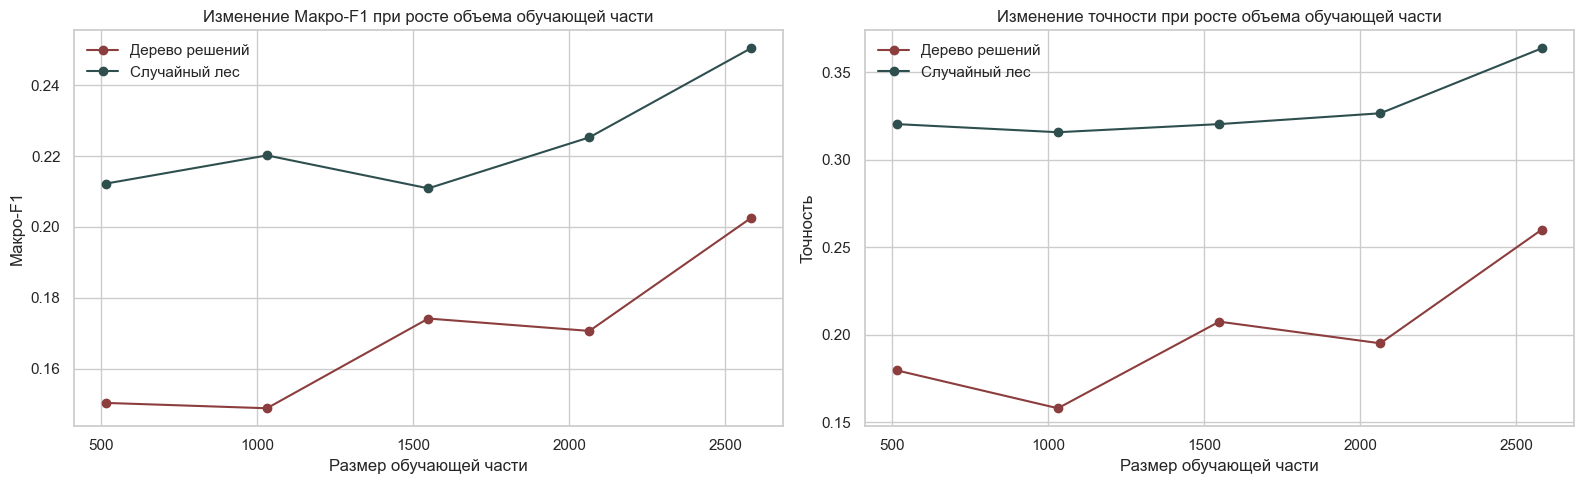

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for model_name, color in [("decision_tree", "#8c3d3d"), ("random_forest", "#2f4f4f")]:
    subset = volume_df[volume_df["Алгоритм"] == MODEL_CONFIGS[model_name]["label"]]
    axes[0].plot(
        subset["Размер обучающей части"],
        subset["Макро-F1"],
        marker="o",
        color=color,
        label=MODEL_CONFIGS[model_name]["label"],
    )
    axes[1].plot(
        subset["Размер обучающей части"],
        subset["Точность"],
        marker="o",
        color=color,
        label=MODEL_CONFIGS[model_name]["label"],
    )

axes[0].set_title("Изменение Макро-F1 при росте объема обучающей части")
axes[0].set_xlabel("Размер обучающей части")
axes[0].set_ylabel("Макро-F1")
axes[0].legend()

axes[1].set_title("Изменение точности при росте объема обучающей части")
axes[1].set_xlabel("Размер обучающей части")
axes[1].set_ylabel("Точность")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Оценка на полном доступном датасете

Для каждого набора данных и каждого алгоритма выбирается лучшая конфигурация по основному разбиению, после чего для неё выполняется стратифицированная кросс-валидация.

In [11]:
cv_rows = []

for dataset_key, dataset_info in dataset_map.items():
    for model_name, model_info in MODEL_CONFIGS.items():
        best_row = experiment_df[
            (experiment_df["dataset_key"] == dataset_key)
            & (experiment_df["Алгоритм"] == model_info["label"])
        ].sort_values(["Макро-F1", "Точность"], ascending=False).iloc[0]
        feature_set = next(key for key, label in FEATURE_SET_LABELS.items() if label == best_row["Набор признаков"])
        fold_df = stratified_cv(dataset_info["frame"], feature_set, model_name, n_splits=5)
        cv_rows.append(
            {
                "Набор данных": dataset_info["label"],
                "Алгоритм": model_info["label"],
                "Набор признаков": FEATURE_SET_LABELS[feature_set],
                "Число признаков": len(FEATURE_SET_DEFINITIONS[feature_set]["feature_order"]),
                "Число наблюдений": int(len(dataset_info["frame"])),
                "Средняя точность": float(fold_df["accuracy"].mean()),
                "Стандартное отклонение точности": float(fold_df["accuracy"].std()),
                "Средний Макро-F1": float(fold_df["f1_macro"].mean()),
                "Стандартное отклонение Макро-F1": float(fold_df["f1_macro"].std()),
                "Средний взвешенный F1": float(fold_df["f1_weighted"].mean()),
                "Стандартное отклонение взвешенного F1": float(fold_df["f1_weighted"].std()),
            }
        )

cv_df = pd.DataFrame(cv_rows).sort_values(["Средний Макро-F1", "Средняя точность"], ascending=[False, False]).reset_index(drop=True)
cv_df.round(4)

,Набор данных,Алгоритм,Набор признаков,Число признаков,Число наблюдений,Средняя точность,Стандартное отклонение точности,Средний Макро-F1,Стандартное отклонение Макро-F1,Средний взвешенный F1,Стандартное отклонение взвешенного F1
0,Малый набор,Случайный лес,39 признаков: постфактум-набор для итогового анализа,39,6340,0.6858,0.0134,0.6735,0.0178,0.6864,0.0136
1,Малый набор,Дерево решений,39 признаков: постфактум-набор для итогового анализа,39,6340,0.3159,0.0178,0.2842,0.0133,0.3325,0.0132
2,Большой набор,Случайный лес,15 признаков: после подачи первого ствола,15,3228,0.3392,0.0182,0.2420,0.0166,0.3451,0.0158
3,Большой набор,Дерево решений,39 признаков: постфактум-набор для итогового анализа,39,3228,0.2435,0.0241,0.1996,0.0108,0.2658,0.0205


## 8. Дополнительный эксперимент: синтетическое расширение обучающей выборки

Основное исследование выполняется на фактическом объёме наблюдений. Дополнительно рассматривается вопрос, можно ли частично компенсировать малое число независимых пожаров с помощью искусственного расширения обучающей части.

В этом блоке сравниваются три варианта для двух алгоритмов:

- без расширения обучающей выборки;
- балансировка классов за счёт копирования наблюдений миноритарных классов;
- синтетическое расширение обучающей выборки по упрощённой схеме типа SMOTE.

Расширение выполняется только для канонического набора. Для усиления эксперимента обучающая часть искусственно увеличивается примерно до `100000` записей с выравниванием классов по целевому числу наблюдений на класс.


In [12]:
from sklearn.neighbors import NearestNeighbors

AUGMENTATION_TARGET_TOTAL = 100000

def build_target_class_counts(y: pd.Series, target_total: int = AUGMENTATION_TARGET_TOTAL):
    y_series = pd.Series(y).reset_index(drop=True)
    class_ids = sorted(y_series.unique().tolist())
    base = target_total // len(class_ids)
    remainder = target_total % len(class_ids)
    targets = {}
    for index, class_id in enumerate(class_ids):
        targets[class_id] = base + (1 if index < remainder else 0)
    return targets


def bootstrap_balance_resample(
    X: pd.DataFrame,
    y: pd.Series,
    *,
    target_counts: dict[int, int],
    random_state: int = SEED,
):
    rng = np.random.default_rng(random_state)
    y_series = pd.Series(y).reset_index(drop=True)
    X_frame = pd.DataFrame(X).reset_index(drop=True)

    x_parts = []
    y_parts = []
    for class_id in sorted(target_counts):
        X_class = X_frame.loc[y_series == class_id].reset_index(drop=True)
        y_class = y_series.loc[y_series == class_id].reset_index(drop=True)
        target_count = int(target_counts[class_id])

        if len(X_class) < target_count:
            sampled_indices = rng.integers(0, len(X_class), size=target_count - len(X_class))
            X_extra = X_class.iloc[sampled_indices].reset_index(drop=True)
            y_extra = pd.Series([class_id] * len(X_extra))
            X_class = pd.concat([X_class, X_extra], ignore_index=True)
            y_class = pd.concat([y_class, y_extra], ignore_index=True)

        x_parts.append(X_class)
        y_parts.append(y_class)

    X_balanced = pd.concat(x_parts, ignore_index=True)
    y_balanced = pd.concat(y_parts, ignore_index=True).astype(int)
    return X_balanced, y_balanced


def smote_like_resample(
    X: pd.DataFrame,
    y: pd.Series,
    *,
    target_counts: dict[int, int],
    random_state: int = SEED,
    k_neighbors: int = 5,
):
    rng = np.random.default_rng(random_state)
    X_frame = pd.DataFrame(X).reset_index(drop=True)
    y_series = pd.Series(y).reset_index(drop=True)
    X_values = X_frame.to_numpy(dtype=float)
    y_values = y_series.to_numpy()

    integer_like = {
        column: np.allclose(X_frame[column].dropna(), np.round(X_frame[column].dropna()))
        for column in X_frame.columns
        if not X_frame[column].dropna().empty
    }

    synthetic_blocks = [X_frame.copy()]
    synthetic_targets = [y_series.copy()]

    for class_id in sorted(target_counts):
        X_class = X_values[y_values == class_id]
        current_count = len(X_class)
        target_count = int(target_counts[class_id])
        if current_count >= target_count:
            continue

        needed = target_count - current_count
        if len(X_class) == 1:
            synth = np.repeat(X_class, repeats=needed, axis=0)
        else:
            neighbors_count = min(k_neighbors, len(X_class) - 1)
            neighbors = NearestNeighbors(n_neighbors=neighbors_count + 1)
            neighbors.fit(X_class)
            indices = neighbors.kneighbors(X_class, return_distance=False)[:, 1:]
            synth_rows = []
            for _ in range(needed):
                base_idx = int(rng.integers(0, len(X_class)))
                pair_idx = int(rng.choice(indices[base_idx]))
                alpha = float(rng.random())
                row = X_class[base_idx] + alpha * (X_class[pair_idx] - X_class[base_idx])
                synth_rows.append(row)
            synth = np.vstack(synth_rows)

        synth_df = pd.DataFrame(synth, columns=X_frame.columns)
        for column, is_integer_like in integer_like.items():
            if is_integer_like:
                synth_df[column] = np.round(synth_df[column])
        synthetic_blocks.append(synth_df)
        synthetic_targets.append(pd.Series([class_id] * len(synth_df)))

    X_smote = pd.concat(synthetic_blocks, ignore_index=True)
    y_smote = pd.concat(synthetic_targets, ignore_index=True).astype(int)
    return X_smote, y_smote


augmentation_experiments = [
    ("Без расширения", None),
    ("Балансировка копированием", bootstrap_balance_resample),
    ("Синтетическое расширение", smote_like_resample),
]

augmentation_rows = []
for model_name, model_info in MODEL_CONFIGS.items():
    operational_row = experiment_df[
        (experiment_df["dataset_key"] == "large")
        & (experiment_df["Алгоритм"] == model_info["label"])
        & (experiment_df["Тип признаков"] != "Постфактум-признаки")
    ].sort_values(["Макро-F1", "Точность"], ascending=False).iloc[0]

    feature_set = next(
        key for key, label in FEATURE_SET_LABELS.items() if label == operational_row["Набор признаков"]
    )
    split_result = fit_random_split(
        large_df,
        feature_set,
        model_name,
        test_size=0.2,
        random_state=SEED,
    )

    X_train_base = split_result["X_train"].reset_index(drop=True)
    y_train_base = split_result["y_train"].reset_index(drop=True)
    X_test_base = split_result["X_test"].reset_index(drop=True)
    y_test_base = split_result["y_test"].reset_index(drop=True)
    target_counts = build_target_class_counts(y_train_base)

    for method_label, sampler in augmentation_experiments:
        if sampler is None:
            X_train_used = X_train_base.copy()
            y_train_used = y_train_base.copy()
        else:
            X_train_used, y_train_used = sampler(
                X_train_base,
                y_train_base,
                target_counts=target_counts,
                random_state=SEED,
            )

        model = build_estimator(model_name)
        model.fit(X_train_used, y_train_used)
        y_pred = model.predict(X_test_base)

        augmentation_rows.append(
            {
                "Алгоритм": model_info["label"],
                "Метод": method_label,
                "Набор признаков": FEATURE_SET_LABELS[feature_set],
                "Число признаков": len(FEATURE_SET_DEFINITIONS[feature_set]["feature_order"]),
                "Размер обучающей части до расширения": int(len(X_train_base)),
                "Размер обучающей части после расширения": int(len(X_train_used)),
                "Размер контрольной части": int(len(X_test_base)),
                "Целевой суммарный размер": int(sum(target_counts.values())),
                "Точность": float(accuracy_score(y_test_base, y_pred)),
                "Макро-F1": float(f1_score(y_test_base, y_pred, average="macro", zero_division=0)),
                "Взвешенная F1": float(f1_score(y_test_base, y_pred, average="weighted", zero_division=0)),
            }
        )

augmentation_df = pd.DataFrame(augmentation_rows).sort_values(
    ["Алгоритм", "Метод"],
    ascending=[True, True],
).reset_index(drop=True)

augmentation_results_path = ARTIFACTS_DIR / "augmentation_all_results.csv"
augmentation_df.to_csv(augmentation_results_path, index=False, encoding="utf-8-sig")

augmentation_best_rows = (
    augmentation_df.sort_values(["Макро-F1", "Точность"], ascending=False)
    .groupby("Алгоритм", as_index=False)
    .first()
)
augmentation_baseline_rows = augmentation_df.loc[augmentation_df["Метод"] == "Без расширения"].reset_index(drop=True)
augmentation_summary = augmentation_baseline_rows.merge(
    augmentation_best_rows[["Алгоритм", "Метод", "Макро-F1", "Точность", "Размер обучающей части после расширения"]],
    on="Алгоритм",
    suffixes=("_база", "_лучший"),
)
augmentation_summary = augmentation_summary.rename(
    columns={
        "Метод_лучший": "Лучший метод",
        "Макро-F1_база": "Макро-F1 без расширения",
        "Макро-F1_лучший": "Макро-F1 лучшего метода",
        "Точность_база": "Точность без расширения",
        "Точность_лучший": "Точность лучшего метода",
        "Размер обучающей части после расширения_лучший": "Размер после лучшего метода",
    }
)

summary_lines = []
for _, row in augmentation_summary.iterrows():
    summary_lines.append(
        f'- **{row["Алгоритм"]}**: от `Макро-F1 = {row["Макро-F1 без расширения"]:.4f}` '
        f'до `Макро-F1 = {row["Макро-F1 лучшего метода"]:.4f}` '
        f'(лучший метод: {row["Лучший метод"]}, размер после расширения: {int(row["Размер после лучшего метода"])})'
    )

display(
    Markdown(
        '**Промежуточный вывод по дополнительному эксперименту.**\n\n'
        + '\n'.join(summary_lines)
        + '\n\nПолная таблица результатов синтетического расширения приведена ниже для обоих алгоритмов и всех рассмотренных способов расширения. '
        + 'Даже после искусственного расширения обучающей части качество остаётся ограниченным, '
        + 'поэтому при текущем количестве независимых пожаров итоговый уровень качества нельзя считать удовлетворительным.'
    )
)
augmentation_df.round(4)


**Промежуточный вывод по дополнительному эксперименту.**

- **Дерево решений**: от `Макро-F1 = 0.1758` до `Макро-F1 = 0.1758` (лучший метод: Без расширения, размер после расширения: 2582)
- **Случайный лес**: от `Макро-F1 = 0.2504` до `Макро-F1 = 0.2504` (лучший метод: Без расширения, размер после расширения: 2582)

Полная таблица результатов синтетического расширения приведена ниже для обоих алгоритмов и всех рассмотренных способов расширения. Даже после искусственного расширения обучающей части качество остаётся ограниченным, поэтому при текущем количестве независимых пожаров итоговый уровень качества нельзя считать удовлетворительным.

,Алгоритм,Метод,Набор признаков,Число признаков,Размер обучающей части до расширения,Размер обучающей части после расширения,Размер контрольной части,Целевой суммарный размер,Точность,Макро-F1,Взвешенная F1
0,Дерево решений,Балансировка копированием,13 признаков: после прибытия,13,2582,100000,646,100000,0.1950,0.1597,0.2022
1,Дерево решений,Без расширения,13 признаков: после прибытия,13,2582,2582,646,100000,0.1920,0.1758,0.2039
2,Дерево решений,Синтетическое расширение,13 признаков: после прибытия,13,2582,100000,646,100000,0.1966,0.1679,0.2228
3,Случайный лес,Балансировка копированием,15 признаков: после подачи первого ствола,15,2582,100000,646,100000,0.3762,0.2369,0.3673
4,Случайный лес,Без расширения,15 признаков: после подачи первого ствола,15,2582,2582,646,100000,0.3638,0.2504,0.3706
5,Случайный лес,Синтетическое расширение,15 признаков: после подачи первого ствола,15,2582,100000,646,100000,0.3142,0.2178,0.3232


## 9. Подбор гиперпараметров моделей

Для дополнительной проверки выполняется подбор гиперпараметров моделей с помощью `Optuna`.

Подбор проводится отдельно:

- для очищенного массива наблюдений;
- для канонического массива наблюдений;
- для дерева решений;
- для случайного леса.

Для каждого сочетания массива наблюдений и алгоритма используется лучший набор признаков, найденный на предыдущих этапах исследования. Целевая функция подбора — `Макро-F1` на внутренней валидационной части обучающей выборки. После завершения подбора модель с лучшими гиперпараметрами обучается на полной обучающей части и сравнивается с базовой конфигурацией на том же контрольном наборе.


In [13]:
import json
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_TRIALS = 18

def suggest_model_params(trial: optuna.trial.Trial, model_name: str):
    if model_name == "decision_tree":
        criterion_options = ["gini", "entropy"]
        if hasattr(DecisionTreeClassifier(), "criterion"):
            criterion_options = ["gini", "entropy", "log_loss"]
        return {
            "criterion": trial.suggest_categorical("criterion", criterion_options),
            "max_depth": trial.suggest_int("max_depth", 3, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 40),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "random_state": SEED,
        }
    if model_name == "random_forest":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 80, 260, step=20),
            "max_depth": trial.suggest_int("max_depth", 4, 24),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 12),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"]),
            "random_state": SEED,
            "n_jobs": -1,
        }
    raise ValueError(f"Неизвестный алгоритм: {model_name}")


def build_estimator_with_params(model_name: str, params: dict):
    if model_name == "decision_tree":
        return DecisionTreeClassifier(**params)
    if model_name == "random_forest":
        return RandomForestClassifier(**params)
    raise ValueError(f"Неизвестный алгоритм: {model_name}")


def run_optuna_tuning(frame: pd.DataFrame, feature_set: str, model_name: str, n_trials: int = OPTUNA_TRIALS):
    prepared = fit_random_split(frame, feature_set, model_name, test_size=0.2, random_state=SEED)
    X_train = prepared["X_train"].reset_index(drop=True)
    y_train = prepared["y_train"].reset_index(drop=True)
    X_test = prepared["X_test"].reset_index(drop=True)
    y_test = prepared["y_test"].reset_index(drop=True)

    train_indices = np.arange(len(X_train))
    inner_train_idx, inner_valid_idx = train_test_split(
        train_indices,
        test_size=0.2,
        random_state=SEED,
        stratify=y_train,
    )
    X_inner_train = X_train.iloc[inner_train_idx].reset_index(drop=True)
    y_inner_train = y_train.iloc[inner_train_idx].reset_index(drop=True)
    X_inner_valid = X_train.iloc[inner_valid_idx].reset_index(drop=True)
    y_inner_valid = y_train.iloc[inner_valid_idx].reset_index(drop=True)

    def objective(trial: optuna.trial.Trial):
        params = suggest_model_params(trial, model_name)
        model = build_estimator_with_params(model_name, params)
        model.fit(X_inner_train, y_inner_train)
        y_valid_pred = model.predict(X_inner_valid)
        return float(f1_score(y_inner_valid, y_valid_pred, average="macro", zero_division=0))

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_trial.params.copy()
    if model_name == "decision_tree":
        best_params["random_state"] = SEED
    if model_name == "random_forest":
        best_params["random_state"] = SEED
        best_params["n_jobs"] = -1

    tuned_model = build_estimator_with_params(model_name, best_params)
    tuned_model.fit(X_train, y_train)
    tuned_pred = tuned_model.predict(X_test)
    tuned_metrics = {
        "accuracy": float(accuracy_score(y_test, tuned_pred)),
        "f1_macro": float(f1_score(y_test, tuned_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_test, tuned_pred, average="weighted", zero_division=0)),
    }

    base_model = build_estimator(model_name)
    base_model.fit(X_train, y_train)
    base_pred = base_model.predict(X_test)
    base_metrics = {
        "accuracy": float(accuracy_score(y_test, base_pred)),
        "f1_macro": float(f1_score(y_test, base_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_test, base_pred, average="weighted", zero_division=0)),
    }

    return {
        "base_metrics": base_metrics,
        "tuned_metrics": tuned_metrics,
        "best_params": best_params,
        "n_trials": int(len(study.trials)),
    }


tuning_rows = []
for dataset_key, dataset_info in dataset_map.items():
    for feature_set in FEATURE_SETS:
        for model_name, model_info in MODEL_CONFIGS.items():
            result = run_optuna_tuning(dataset_info["frame"], feature_set, model_name)
            tuning_rows.append(
                {
                    "dataset_key": dataset_key,
                    "feature_set_key": feature_set,
                    "Набор данных": dataset_info["label"],
                    "Алгоритм": model_info["label"],
                    "Тип признаков": FEATURE_SET_FAMILY[feature_set],
                    "Набор признаков": FEATURE_SET_LABELS[feature_set],
                    "Число признаков": len(FEATURE_SET_DEFINITIONS[feature_set]["feature_order"]),
                    "Макро-F1 базовой модели": result["base_metrics"]["f1_macro"],
                    "Макро-F1 после подбора": result["tuned_metrics"]["f1_macro"],
                    "Прирост Макро-F1": result["tuned_metrics"]["f1_macro"] - result["base_metrics"]["f1_macro"],
                    "Точность базовой модели": result["base_metrics"]["accuracy"],
                    "Точность после подбора": result["tuned_metrics"]["accuracy"],
                    "Прирост точности": result["tuned_metrics"]["accuracy"] - result["base_metrics"]["accuracy"],
                    "Число испытаний": result["n_trials"],
                    "Лучшие параметры": json.dumps(result["best_params"], ensure_ascii=False),
                }
            )

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    ["Набор данных", "Алгоритм", "Число признаков", "Набор признаков"],
    ascending=[True, True, True, True],
).reset_index(drop=True)

tuning_results_path = ARTIFACTS_DIR / "optuna_all_results.csv"
tuning_df.to_csv(tuning_results_path, index=False, encoding="utf-8-sig")

best_tuned_row = tuning_df.sort_values(["Макро-F1 после подбора", "Точность после подбора"], ascending=False).iloc[0]
display(
    Markdown(
        f'''
**Промежуточный вывод по подбору гиперпараметров.**

- Наилучшая конфигурация после подбора получена для сочетания **{best_tuned_row["Алгоритм"]} / {best_tuned_row["Набор данных"]} / {best_tuned_row["Набор признаков"]}**.
- Для этой конфигурации `Макро-F1` изменился с `{best_tuned_row["Макро-F1 базовой модели"]:.4f}` до `{best_tuned_row["Макро-F1 после подбора"]:.4f}`.
- Полная таблица результатов подбора приведена ниже для всех сочетаний массивов наблюдений, наборов признаков и алгоритмов.
'''
    )
)
tuning_df.round(4)



**Промежуточный вывод по подбору гиперпараметров.**

- Наилучшая конфигурация после подбора получена для сочетания **Случайный лес / Малый набор / 39 признаков: постфактум-набор для итогового анализа**.
- Для этой конфигурации `Макро-F1` изменился с `0.6707` до `0.7801`.
- Полная таблица результатов подбора приведена ниже для всех сочетаний массивов наблюдений, наборов признаков и алгоритмов.


,dataset_key,feature_set_key,Набор данных,Алгоритм,Тип признаков,Набор признаков,Число признаков,Макро-F1 базовой модели,Макро-F1 после подбора,Прирост Макро-F1,Точность базовой модели,Точность после подбора,Прирост точности,Число испытаний,Лучшие параметры
0,large,dispatch_initial_safe,Большой набор,Дерево решений,Базовые признаки,10 признаков: при сообщении о пожаре,10,0.1716,0.1809,0.0093,0.2012,0.3854,0.1842,18,"{""criterion"": ""gini"", ""max_depth"": 20, ""min_samples_split"": 30, ""min_samples_leaf"": 12, ""class_weight"": null, ""random_state"": 42}"
1,large,arrival_update_safe,Большой набор,Дерево решений,Базовые признаки,13 признаков: после прибытия,13,0.1758,0.1825,0.0068,0.1920,0.3313,0.1393,18,"{""criterion"": ""log_loss"", ""max_depth"": 17, ""min_samples_split"": 13, ""min_samples_leaf"": 2, ""class_weight"": null, ""random_state"": 42}"
2,large,first_hose_update_safe,Большой набор,Дерево решений,Базовые признаки,15 признаков: после подачи первого ствола,15,0.1514,0.1874,0.0359,0.1625,0.3483,0.1858,18,"{""criterion"": ""entropy"", ""max_depth"": 16, ""min_samples_split"": 32, ""min_samples_leaf"": 2, ""class_weight"": null, ""random_state"": 42}"
3,large,enhanced_tactical,Большой набор,Дерево решений,Обогащённые признаки,31 признак: расширенный оперативный набор,31,0.1632,0.1767,0.0135,0.1796,0.3669,0.1873,18,"{""criterion"": ""log_loss"", ""max_depth"": 14, ""min_samples_split"": 39, ""min_samples_leaf"": 14, ""class_weight"": null, ""random_state"": 42}"
4,large,retrospective_full_safe,Большой набор,Дерево решений,Постфактум-признаки,39 признаков: постфактум-набор для итогового анализа,39,0.2025,0.1719,-0.0306,0.2601,0.3762,0.1161,18,"{""criterion"": ""entropy"", ""max_depth"": 8, ""min_samples_split"": 17, ""min_samples_leaf"": 6, ""class_weight"": null, ""random_state"": 42}"
5,large,dispatch_initial_safe,Большой набор,Случайный лес,Базовые признаки,10 признаков: при сообщении о пожаре,10,0.2278,0.2404,0.0126,0.3158,0.3251,0.0093,18,"{""n_estimators"": 260, ""max_depth"": 13, ""min_samples_split"": 15, ""min_samples_leaf"": 1, ""max_features"": null, ""class_weight"": ""balanced"", ""random_state"": 42,..."
6,large,arrival_update_safe,Большой набор,Случайный лес,Базовые признаки,13 признаков: после прибытия,13,0.2278,0.2333,0.0055,0.3390,0.3622,0.0232,18,"{""n_estimators"": 220, ""max_depth"": 18, ""min_samples_split"": 11, ""min_samples_leaf"": 3, ""max_features"": null, ""class_weight"": ""balanced"", ""random_state"": 42,..."
7,large,first_hose_update_safe,Большой набор,Случайный лес,Базовые признаки,15 признаков: после подачи первого ствола,15,0.2504,0.2406,-0.0098,0.3638,0.3700,0.0062,18,"{""n_estimators"": 240, ""max_depth"": 17, ""min_samples_split"": 11, ""min_samples_leaf"": 1, ""max_features"": null, ""class_weight"": ""balanced"", ""random_state"": 42,..."
8,large,enhanced_tactical,Большой набор,Случайный лес,Обогащённые признаки,31 признак: расширенный оперативный набор,31,0.2277,0.2336,0.0060,0.3560,0.3375,-0.0186,18,"{""n_estimators"": 260, ""max_depth"": 13, ""min_samples_split"": 16, ""min_samples_leaf"": 1, ""max_features"": null, ""class_weight"": ""balanced"", ""random_state"": 42,..."
9,large,retrospective_full_safe,Большой набор,Случайный лес,Постфактум-признаки,39 признаков: постфактум-набор для итогового анализа,39,0.2305,0.2497,0.0192,0.3669,0.3684,0.0015,18,"{""n_estimators"": 260, ""max_depth"": 19, ""min_samples_split"": 30, ""min_samples_leaf"": 9, ""max_features"": ""log2"", ""class_weight"": ""balanced_subsample"", ""random..."


## 10. Итоговые модели и выводы


In [14]:
overall_best_row = experiment_df.sort_values(["Макро-F1", "Точность"], ascending=False).iloc[0]
overall_best_feature_set = next(
    key for key, label in FEATURE_SET_LABELS.items() if label == overall_best_row["Набор признаков"]
)
overall_best_model_name = next(
    key for key, value in MODEL_CONFIGS.items() if value["label"] == overall_best_row["Алгоритм"]
)
overall_dataset_key = overall_best_row["dataset_key"]
overall_dataset = dataset_map[overall_dataset_key]["frame"]
overall_best_result = fit_random_split(overall_dataset, overall_best_feature_set, overall_best_model_name, test_size=0.2, random_state=SEED)

best_dt_row = experiment_df[experiment_df["Алгоритм"] == "Дерево решений"].sort_values(["Макро-F1", "Точность"], ascending=False).iloc[0]
best_dt_feature_set = next(key for key, label in FEATURE_SET_LABELS.items() if label == best_dt_row["Набор признаков"])
best_dt_dataset = dataset_map[best_dt_row["dataset_key"]]["frame"]
best_dt_result = fit_random_split(best_dt_dataset, best_dt_feature_set, "decision_tree", test_size=0.2, random_state=SEED)

overall_importance_df = (
    pd.DataFrame(
        {
            "feature": overall_best_result["feature_order"],
            "importance": overall_best_result["model"].feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
overall_importance_df

,feature,importance
0,region_code,0.079835
1,source_item_code,0.061561
2,assets_saved,0.060919
3,distance_to_station,0.057465
4,month,0.053882
5,t_extinguished_min,0.052133
6,direct_damage,0.050667
7,t_detect_min,0.050343
8,t_contained_min,0.048755
9,t_arrival_min,0.047507


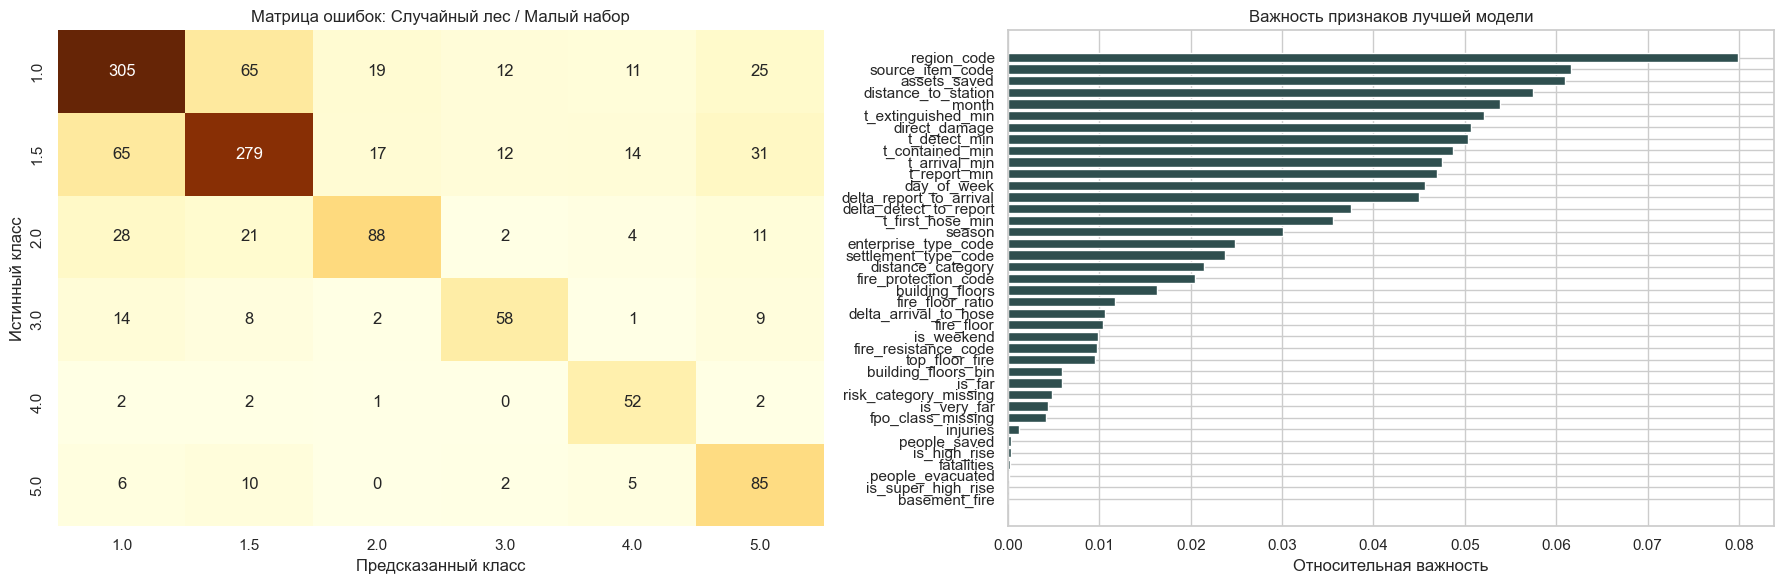

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plot_confusion(
    axes[0],
    overall_best_result["metrics"]["confusion_matrix"],
    f"Матрица ошибок: {overall_best_row['Алгоритм']} / {overall_best_row['Набор данных']}",
)
axes[1].barh(
    overall_importance_df["feature"][::-1],
    overall_importance_df["importance"][::-1],
    color="#2f4f4f" if overall_best_model_name == "random_forest" else "#8c3d3d",
)
axes[1].set_title("Важность признаков лучшей модели")
axes[1].set_xlabel("Относительная важность")
plt.tight_layout()
plt.show()


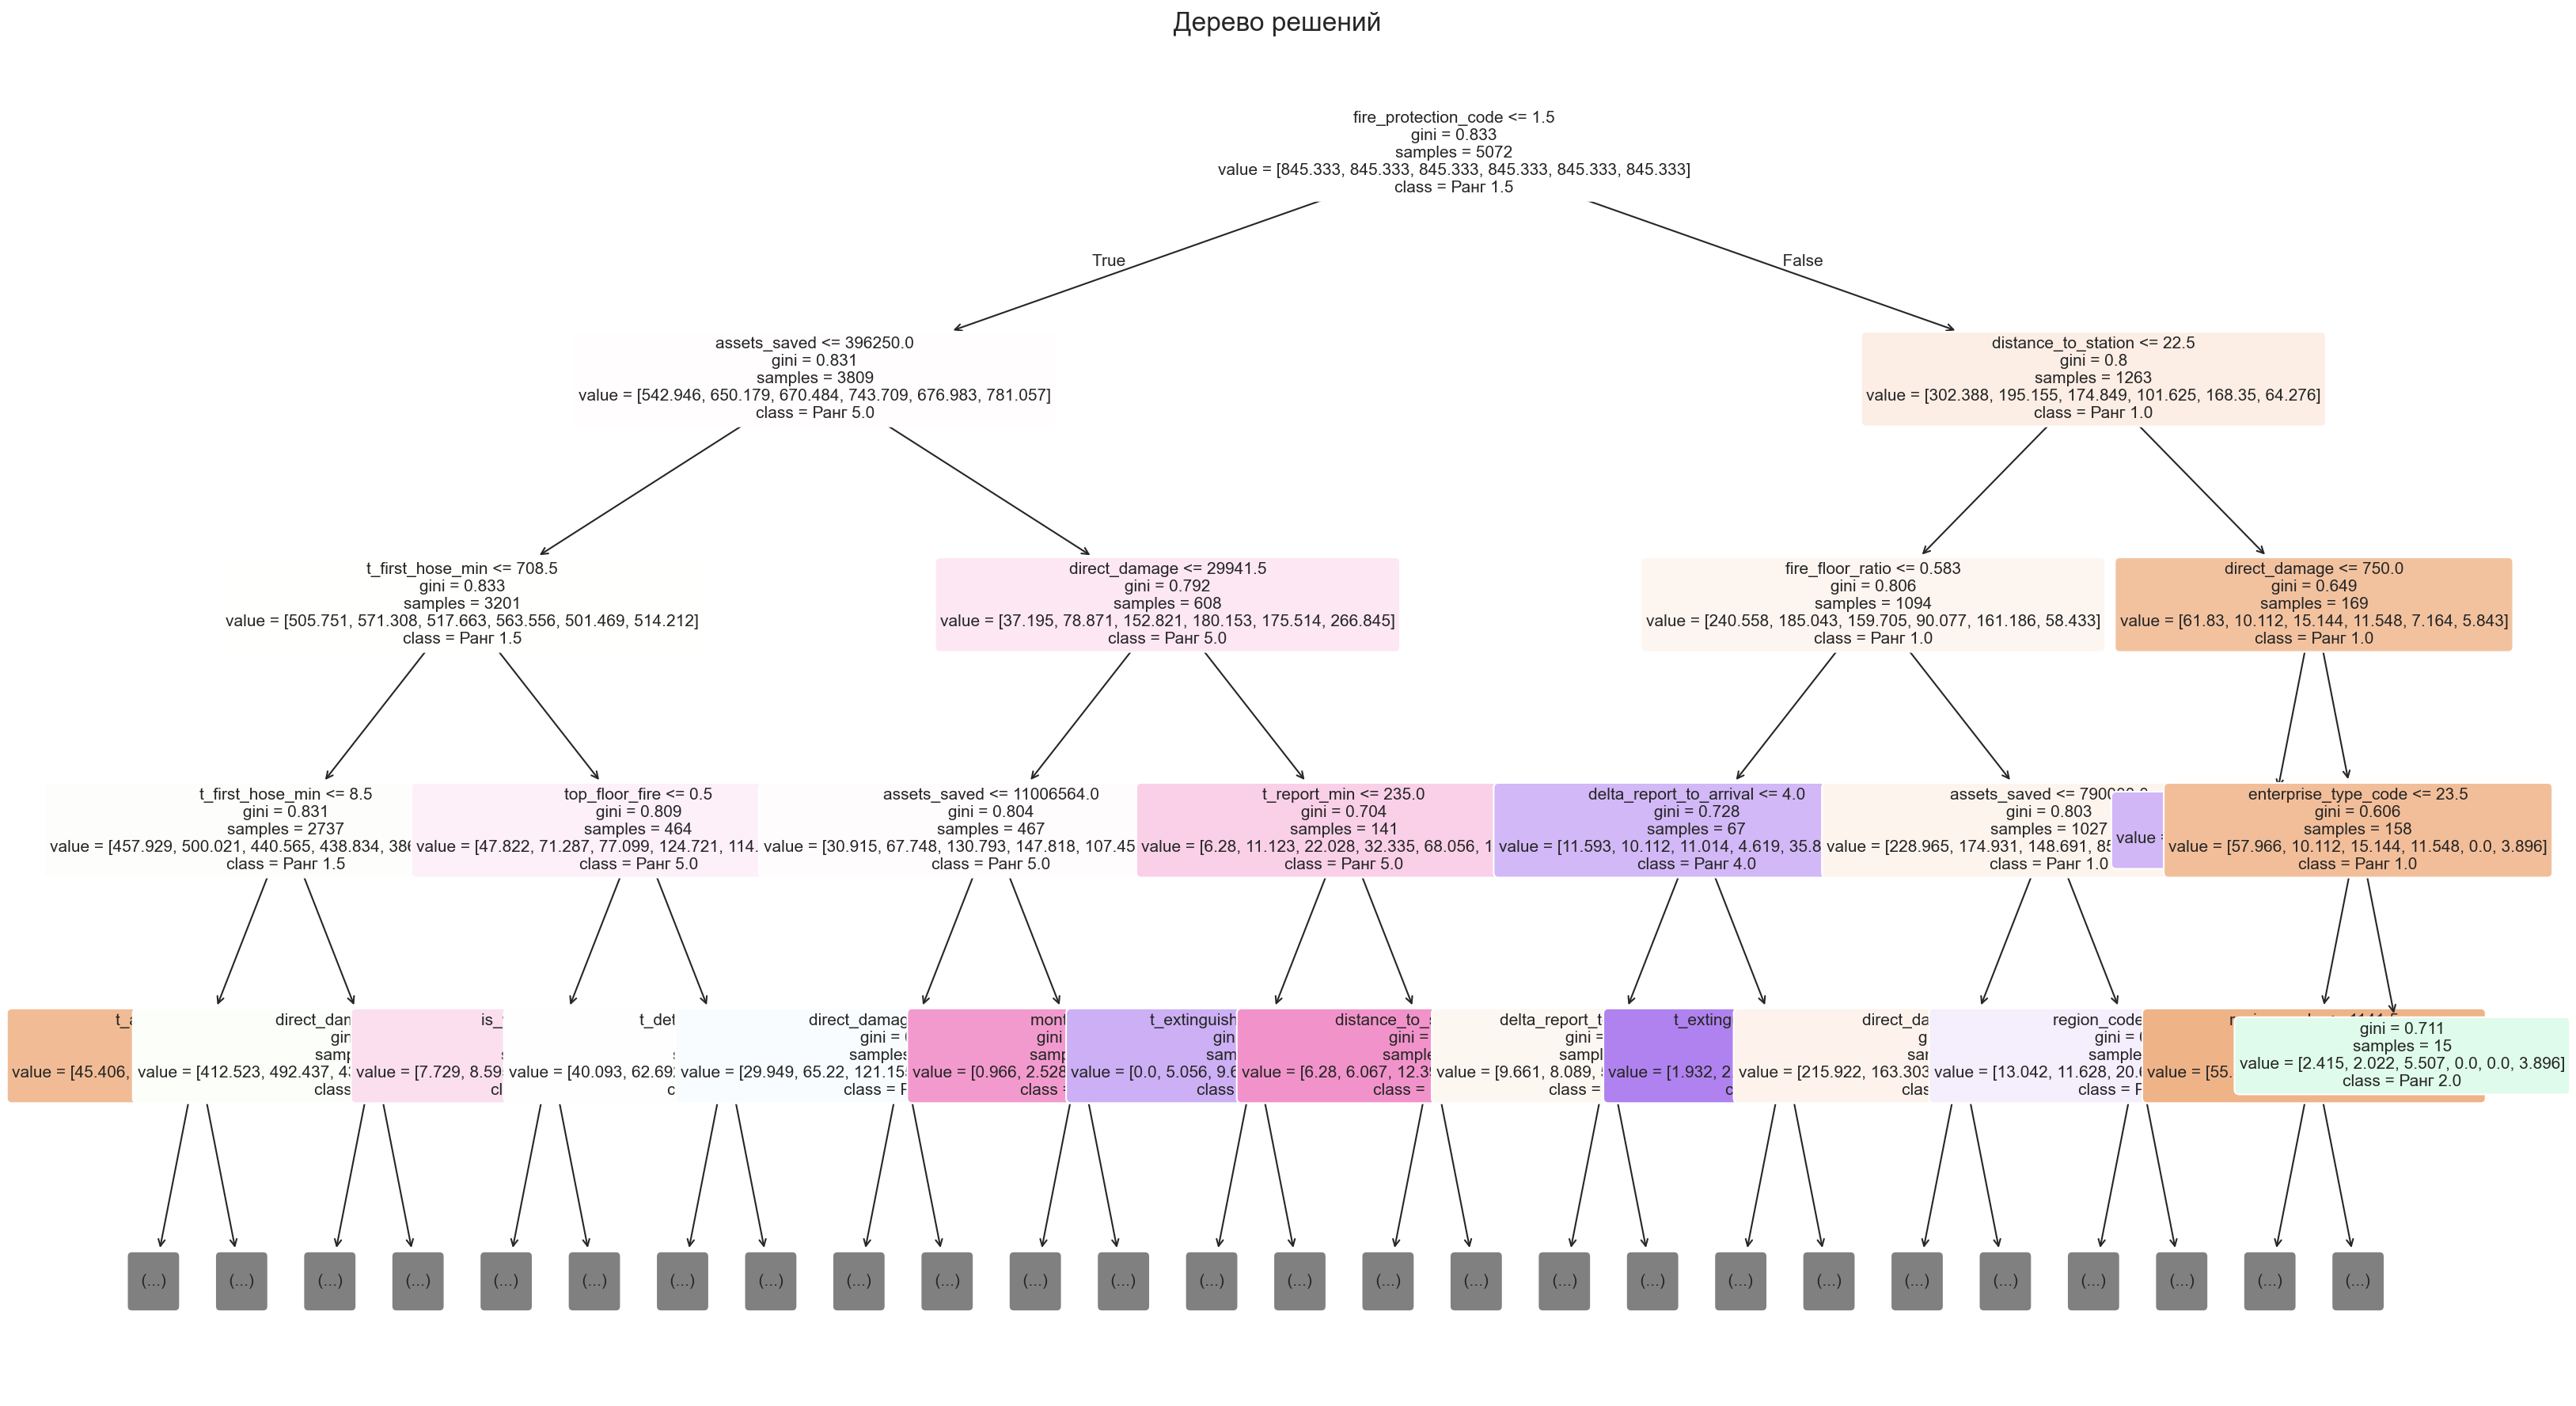

In [16]:
tree_image_path = ARTIFACTS_DIR / "best_decision_tree.png"
visualize_tree(
    best_dt_result["model"],
    feature_names=best_dt_result["feature_order"],
    class_names=[f"Ранг {value}" for value in CLASS_LABELS],
    output_path=tree_image_path,
    max_depth=4,
    figsize=(22, 12),
)
display(Image(filename=str(tree_image_path)))


In [17]:
best_large_rf = experiment_df[
    (experiment_df["dataset_key"] == "large") & (experiment_df["Алгоритм"] == "Случайный лес")
].sort_values(["Макро-F1", "Точность"], ascending=False).iloc[0]
best_large_dt = experiment_df[
    (experiment_df["dataset_key"] == "large") & (experiment_df["Алгоритм"] == "Дерево решений")
].sort_values(["Макро-F1", "Точность"], ascending=False).iloc[0]
best_cv_row = cv_df.iloc[0]
best_augmented_dt = augmentation_summary.loc[augmentation_summary["Алгоритм"] == "Дерево решений"].iloc[0]
best_augmented_rf = augmentation_summary.loc[augmentation_summary["Алгоритм"] == "Случайный лес"].iloc[0]
best_tuning_row = tuning_df.sort_values(["Макро-F1 после подбора", "Точность после подбора"], ascending=False).iloc[0]

early_operational_row = tuning_df[
    (tuning_df["dataset_key"] == "small")
    & (tuning_df["feature_set_key"] == "dispatch_initial_safe")
    & (tuning_df["Алгоритм"] == "Случайный лес")
].iloc[0]

display(
    Markdown(
        f'''
### Итоговые выводы

1. Наилучший результат среди всех рассмотренных комбинаций показала модель **{overall_best_row["Алгоритм"]}** на наборе **{overall_best_row["Набор данных"]}** с набором признаков **{overall_best_row["Набор признаков"]}**.
2. Для большого набора данных лучшее дерево решений дало `Макро-F1 = {best_large_dt["Макро-F1"]:.4f}`, лучший случайный лес — `Макро-F1 = {best_large_rf["Макро-F1"]:.4f}`.
3. Набор из `10` признаков соответствует начальному этапу после сообщения о пожаре, набор из `13` признаков — этапу после прибытия, набор из `15` признаков — этапу после подачи первого ствола.
4. Набор из `31` признака представляет собой расширенный оперативный набор, а набор из `39` признаков — постфактум-набор для итогового анализа после завершения пожара и сбора полной информации.
5. Полные таблицы результатов без подбора гиперпараметров, с синтетическим расширением и после подбора гиперпараметров приведены в соответствующих разделах для всех рассмотренных сочетаний массивов наблюдений, наборов признаков и алгоритмов.
6. По стратифицированной кросс-валидации на полном доступном датасете лучший результат показала конфигурация **{best_cv_row["Алгоритм"]} / {best_cv_row["Набор данных"]} / {best_cv_row["Набор признаков"]}** со `Средним Макро-F1 = {best_cv_row["Средний Макро-F1"]:.4f}`.
7. При текущем объёме независимых наблюдений качество дерева решений на дедуплицированном наборе остаётся низким, поэтому полученный уровень качества нельзя считать удовлетворительным для практического прогноза без расширения данных.
8. Дополнительный эксперимент с искусственным расширением обучающей части показал:
   - для дерева решений переход от `Макро-F1 = {best_augmented_dt["Макро-F1 без расширения"]:.4f}` до `Макро-F1 = {best_augmented_dt["Макро-F1 лучшего метода"]:.4f}`;
   - для случайного леса переход от `Макро-F1 = {best_augmented_rf["Макро-F1 без расширения"]:.4f}` до `Макро-F1 = {best_augmented_rf["Макро-F1 лучшего метода"]:.4f}`.
9. Для раннего этапа, когда используется только набор из `10` признаков при сообщении о пожаре, подбор гиперпараметров для случайного леса на очищенном наборе увеличил `Макро-F1` с `{early_operational_row["Макро-F1 базовой модели"]:.4f}` до `{early_operational_row["Макро-F1 после подбора"]:.4f}`, а точность — с `{early_operational_row["Точность базовой модели"]:.4f}` до `{early_operational_row["Точность после подбора"]:.4f}`.
10. Подбор гиперпараметров с помощью Optuna дал лучший общий результат для конфигурации **{best_tuning_row["Алгоритм"]} / {best_tuning_row["Набор данных"]} / {best_tuning_row["Набор признаков"]}** и изменил `Макро-F1` с `{best_tuning_row["Макро-F1 базовой модели"]:.4f}` до `{best_tuning_row["Макро-F1 после подбора"]:.4f}`.
11. Искусственное расширение и подбор гиперпараметров полезны как дополнительные меры, но не заменяют расширение набора реальными независимыми пожарами.
'''
    )
)



### Итоговые выводы

1. Наилучший результат среди всех рассмотренных комбинаций показала модель **Случайный лес** на наборе **Малый набор** с набором признаков **39 признаков: постфактум-набор для итогового анализа**.
2. Для большого набора данных лучшее дерево решений дало `Макро-F1 = 0.2025`, лучший случайный лес — `Макро-F1 = 0.2504`.
3. Набор из `10` признаков соответствует начальному этапу после сообщения о пожаре, набор из `13` признаков — этапу после прибытия, набор из `15` признаков — этапу после подачи первого ствола.
4. Набор из `31` признака представляет собой расширенный оперативный набор, а набор из `39` признаков — постфактум-набор для итогового анализа после завершения пожара и сбора полной информации.
5. Полные таблицы результатов без подбора гиперпараметров, с синтетическим расширением и после подбора гиперпараметров приведены в соответствующих разделах для всех рассмотренных сочетаний массивов наблюдений, наборов признаков и алгоритмов.
6. По стратифицированной кросс-валидации на полном доступном датасете лучший результат показала конфигурация **Случайный лес / Малый набор / 39 признаков: постфактум-набор для итогового анализа** со `Средним Макро-F1 = 0.6735`.
7. При текущем объёме независимых наблюдений качество дерева решений на дедуплицированном наборе остаётся низким, поэтому полученный уровень качества нельзя считать удовлетворительным для практического прогноза без расширения данных.
8. Дополнительный эксперимент с искусственным расширением обучающей части показал:
   - для дерева решений переход от `Макро-F1 = 0.1758` до `Макро-F1 = 0.1758`;
   - для случайного леса переход от `Макро-F1 = 0.2504` до `Макро-F1 = 0.2504`.
9. Для раннего этапа, когда используется только набор из `10` признаков при сообщении о пожаре, подбор гиперпараметров для случайного леса на очищенном наборе увеличил `Макро-F1` с `0.4411` до `0.6104`, а точность — с `0.4756` до `0.6372`.
10. Подбор гиперпараметров с помощью Optuna дал лучший общий результат для конфигурации **Случайный лес / Малый набор / 39 признаков: постфактум-набор для итогового анализа** и изменил `Макро-F1` с `0.6707` до `0.7801`.
11. Искусственное расширение и подбор гиперпараметров полезны как дополнительные меры, но не заменяют расширение набора реальными независимыми пожарами.
